# Project 19 — Coal-Mining Disasters (Poisson changepoint)

**Tier 4 · Advanced** | **Author:** Truong Van Thien, PhD (TS. Trương Văn Thiên) | **Date:** 12-06-2026 | **Model tag:** Opus48

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tvthienbk/biofx_python/blob/main/bayesian-workflow-20/P19_coal-changepoint/P19_coal-changepoint_12-06-2026_Opus48.ipynb)

The classic **changepoint** problem: annual counts of British coal-mining disasters (1851–1961) drop
sharply at some unknown year. We model a **discrete switchpoint** with a Poisson rate before and after.
This is the project where **the "0 divergences" rule does not apply** — a discrete latent variable forces
PyMC into **compound sampling** (Metropolis for the switchpoint + NUTS for the rates), so diagnostics
become **model-aware** (§6, §7.8). We also build the **marginalized** version that restores clean NUTS.

## Learning objectives
1. Build a **discrete-latent** changepoint model and read the switchpoint's posterior.
2. Understand **compound sampling** and why the divergence-count criterion is waived here.
3. Build the **marginalized** (sum-over-switchpoint) model and recover full-NUTS diagnostics.
4. Run **SBC** (Tier 4) on the rates, and compare the changepoint vs a constant-rate model with LOO.

## Setup

In [1]:
# !pip install -q "pymc>=5.16" "arviz>=0.18" "pandas>=2.0" "scipy>=1.11" "matplotlib>=3.7"
import os, io, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import pymc as pm, arviz as az
import pytensor.tensor as pt
import scipy.stats as st
warnings.simplefilter("ignore"); az.style.use("arviz-darkgrid")
RANDOM_SEED = 19
rng = np.random.default_rng(RANDOM_SEED)
print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 5.28.5 | arviz 0.23.4


## Data — hardcoded series (Jarrett 1979), cite the primary source
Annual counts of coal-mining disasters in Britain, 1851–1961 (111 years). Tiny and canonical, so we
**hardcode** it (§7.4) and write a cache copy for completeness.

years: 1851 - 1961 | n = 111 | total disasters: 191


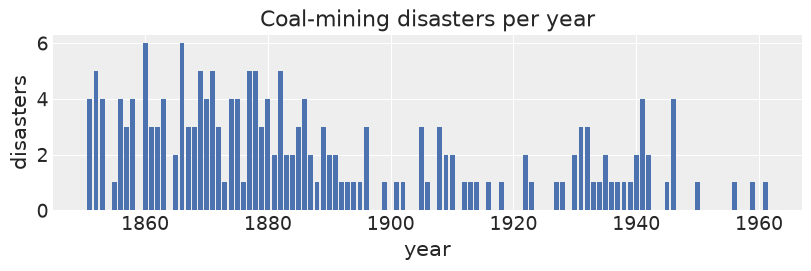

In [2]:
disasters = np.array([
4,5,4,0,1,4,3,4,0,6,3,3,4,0,2,6,3,3,5,4,5,3,1,4,4,1,5,5,3,4,2,5,2,2,3,4,2,1,3,2,
2,1,1,1,1,3,0,0,1,0,1,1,0,0,3,1,0,3,2,2,0,1,1,1,0,1,0,1,0,0,0,2,1,0,0,0,1,1,0,2,
3,3,1,1,2,1,1,1,1,2,4,2,0,0,1,4,0,0,0,1,0,0,0,0,0,1,0,0,1,0,1])
years = np.arange(1851, 1851+len(disasters))
n = len(disasters)
os.makedirs("data", exist_ok=True)
pd.DataFrame({"year":years,"disasters":disasters}).to_csv("data/coal_disasters.csv", index=False)
print("years:", years[0], "-", years[-1], "| n =", n, "| total disasters:", disasters.sum())
plt.figure(figsize=(8,2.6)); plt.bar(years, disasters, color="#4c72b0")
plt.xlabel("year"); plt.ylabel("disasters"); plt.title("Coal-mining disasters per year"); plt.show()

## Stage 0 — Fake-data parameter recovery [required]
Simulate a series with a **known** switch at 1900, early rate 3.2, late rate 0.9; fit the discrete
model; confirm the switchpoint posterior concentrates near 1900 and the rates are recovered.

In [3]:
sw_t, e_t, l_t = 1900, 3.2, 0.9
y_sim = np.where(years < sw_t, rng.poisson(e_t, n), rng.poisson(l_t, n))
with pm.Model() as m0:
    s = pm.DiscreteUniform("s", lower=0, upper=n-1)
    e = pm.Exponential("e", 1.0); l = pm.Exponential("l", 1.0)
    rate = pm.math.switch(np.arange(n) < s, e, l)
    pm.Poisson("y", rate, observed=y_sim)
    idata0 = pm.sample(2000, tune=2000, chains=4, random_seed=RANDOM_SEED, progressbar=False)
s_post_year = 1851 + idata0.posterior["s"].values.ravel()
print(f"switchpoint posterior median year: {np.median(s_post_year):.0f} (truth {sw_t})")
print(f"early rate: {idata0.posterior['e'].mean().item():.2f} (truth {e_t}) | late rate: {idata0.posterior['l'].mean().item():.2f} (truth {l_t})")
print("RECOVERY OK:", abs(np.median(s_post_year)-sw_t)<=5)

Multiprocess sampling (4 chains in 2 jobs)


CompoundStep


>Metropolis: [s]


>NUTS: [e, l]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 10 seconds.


switchpoint posterior median year: 1902 (truth 1900)
early rate: 3.12 (truth 3.2) | late rate: 0.86 (truth 0.9)
RECOVERY OK: True


## Stage 3 — Model A: discrete switchpoint (compound sampling)
$$s\sim\mathrm{DiscreteUniform}(0,n{-}1),\quad e,\ell\sim\mathrm{Exponential}(1),\quad
\text{rate}_i = e\ \text{if}\ i<s\ \text{else}\ \ell,\quad y_i\sim\mathrm{Poisson}(\text{rate}_i).$$
Because `s` is **discrete**, PyMC cannot use NUTS for it; it assigns a **compound step**
(Metropolis on `s`, NUTS on `e`, `ℓ`).

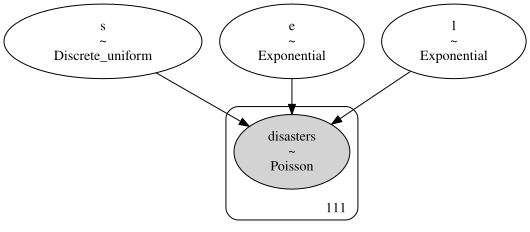

In [4]:
with pm.Model() as model_disc:
    s = pm.DiscreteUniform("s", lower=0, upper=n-1)
    e = pm.Exponential("e", 1.0); l = pm.Exponential("l", 1.0)
    rate = pm.math.switch(np.arange(n) < s, e, l)
    disasters_obs = pm.Poisson("disasters", rate, observed=disasters)
try:
    display(pm.model_to_graphviz(model_disc))
except Exception as ex:
    print("graphviz unavailable:", type(ex).__name__)

## Stage 4 — Prior predictive (outcome = counts)

Sampling: [disasters, e, l, s]


prior-predictive counts: 5-95% = [0, 4], frac of zeros 0.49


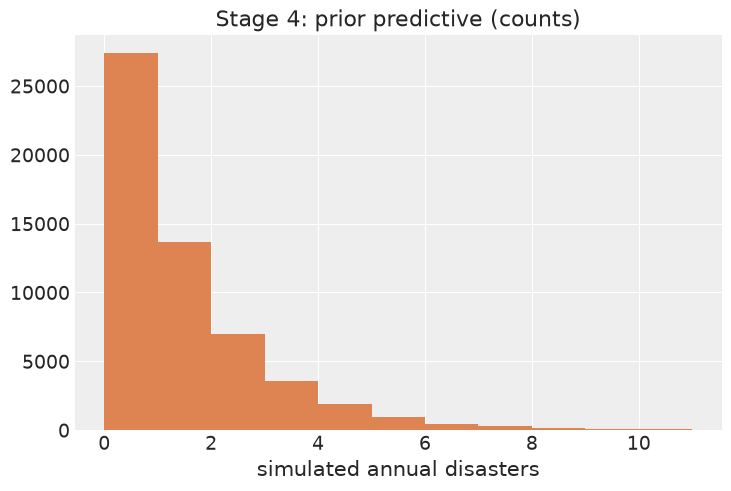

In [5]:
with model_disc:
    prior = pm.sample_prior_predictive(samples=500, random_seed=RANDOM_SEED)
pp = prior.prior_predictive["disasters"].values.reshape(-1)
print(f"prior-predictive counts: 5-95% = [{np.percentile(pp,5):.0f}, {np.percentile(pp,95):.0f}], frac of zeros {np.mean(pp==0):.2f}")
plt.hist(pp, bins=range(0,12), color="#dd8452"); plt.xlabel("simulated annual disasters"); plt.title("Stage 4: prior predictive (counts)"); plt.show()

## Stage 5 — Fit (compound step) — note the sampler PyMC selects

In [6]:
t0=time.time()
with model_disc:
    idata_d = pm.sample(3000, tune=2000, chains=4, random_seed=RANDOM_SEED, progressbar=False,
                        idata_kwargs={"log_likelihood": True})
print(f"wall-clock {time.time()-t0:.1f}s")
print("sampler: PyMC selected a CompoundStep -> Metropolis for the discrete switchpoint s + NUTS for the rates e, l")

Multiprocess sampling (4 chains in 2 jobs)


CompoundStep


>Metropolis: [s]


>NUTS: [e, l]


Sampling 4 chains for 2_000 tune and 3_000 draw iterations (8_000 + 12_000 draws total) took 12 seconds.


wall-clock 12.9s
sampler: PyMC selected a CompoundStep -> Metropolis for the discrete switchpoint s + NUTS for the rates e, l


## Stage 6 — Diagnostics (MODEL-AWARE)
For a compound/discrete-latent model the **divergence-count criterion is waived** (§6, §9). We judge
**per-block R̂/ESS** and confirm the **discrete switchpoint mixes** (its posterior is concentrated, not
stuck).

     mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk  ess_tail
e   3.062  0.290   2.545    3.631    1.0    7577.0    8353.0
l   0.937  0.118   0.709    1.149    1.0    9184.0    8315.0
s  39.968  2.548  35.000   44.000    1.0    1740.0    1663.0

switchpoint: median year 1891, 94% HDI [1887, 1897]
note: 'divergences' are not the NUTS criterion here (compound step) — we check R-hat/ESS and switchpoint mixing instead.


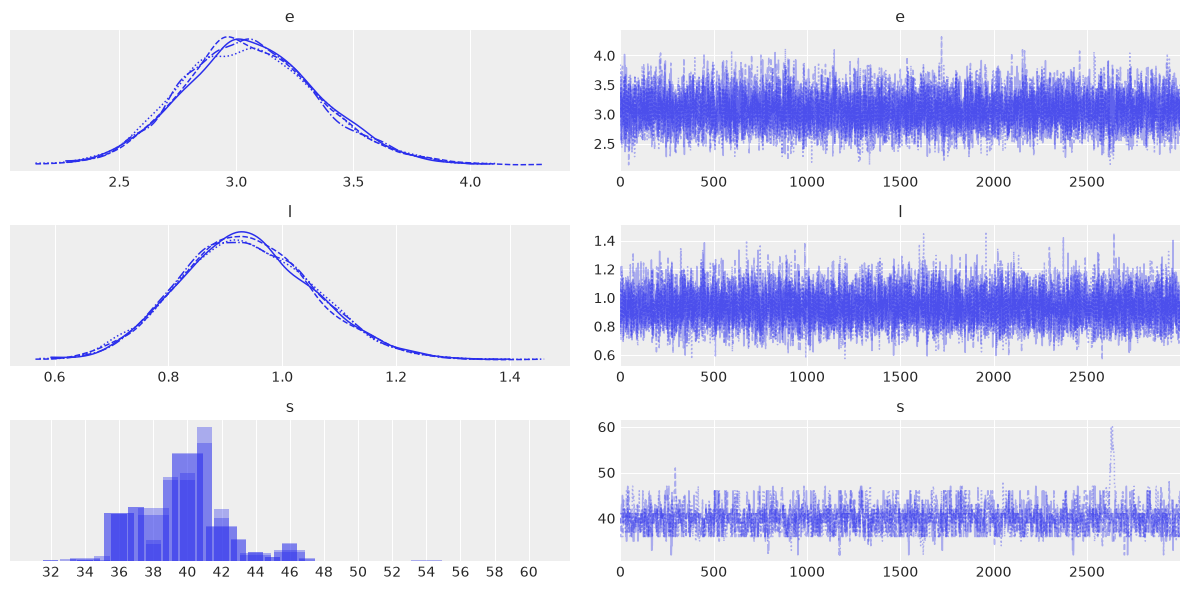

In [7]:
print(az.summary(idata_d, var_names=["e","l","s"], hdi_prob=0.94)[["mean","sd","hdi_3%","hdi_97%","r_hat","ess_bulk","ess_tail"]])
sy = 1851 + idata_d.posterior["s"].values.ravel()
print(f"\nswitchpoint: median year {np.median(sy):.0f}, 94% HDI [{np.percentile(sy,3):.0f}, {np.percentile(sy,97):.0f}]")
print("note: 'divergences' are not the NUTS criterion here (compound step) — we check R-hat/ESS and switchpoint mixing instead.")
az.plot_trace(idata_d, var_names=["e","l","s"]); plt.tight_layout(); plt.show()

## Stage 7 — Interpretation

Before the switch (~1891): ~3.06 disasters/year. After: ~0.94/year — a 69% drop.


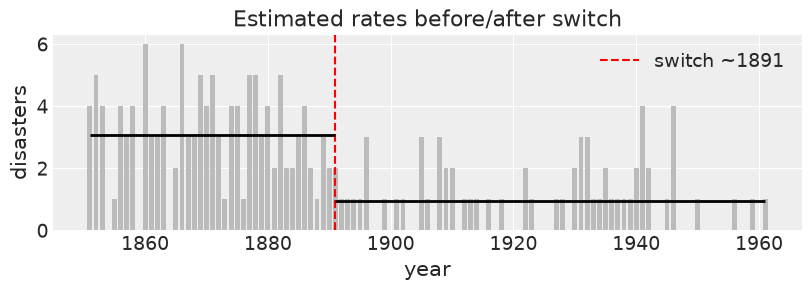

In [8]:
em = idata_d.posterior["e"].mean().item(); lm = idata_d.posterior["l"].mean().item()
print(f"Before the switch (~{np.median(sy):.0f}): ~{em:.2f} disasters/year. After: ~{lm:.2f}/year — a {100*(1-lm/em):.0f}% drop.")
plt.figure(figsize=(8,2.8)); plt.bar(years, disasters, color="#bbb")
plt.axvline(np.median(sy), color="r", ls="--", label=f"switch ~{np.median(sy):.0f}")
plt.hlines(em, years[0], np.median(sy), color="k", lw=2); plt.hlines(lm, np.median(sy), years[-1], color="k", lw=2)
plt.legend(); plt.title("Estimated rates before/after switch"); plt.xlabel("year"); plt.ylabel("disasters"); plt.show()

## Stage 8 — Posterior predictive check (count discrepancy stats)

In [9]:
with model_disc:
    idata_d.extend(pm.sample_posterior_predictive(idata_d, random_seed=RANDOM_SEED, progressbar=False))
ppc = idata_d.posterior_predictive["disasters"].values.reshape(-1, n)
print(f"proportion of zero-years: obs={np.mean(disasters==0):.2f}  bayes-p={(np.mean(ppc==0,axis=1)>=np.mean(disasters==0)).mean():.2f}")
print(f"max annual count:         obs={disasters.max()}     bayes-p={(ppc.max(1)>=disasters.max()).mean():.2f}")
print(f"total disasters:          obs={disasters.sum()}   bayes-p={(ppc.sum(1)>=disasters.sum()).mean():.2f}")

Sampling: [disasters]


proportion of zero-years: obs=0.29  bayes-p=0.38
max annual count:         obs=6     bayes-p=0.97
total disasters:          obs=191   bayes-p=0.46


## Stage 9 — Comparison: changepoint vs constant-rate Poisson (LOO)

In [10]:
with pm.Model() as model_const:
    r = pm.Exponential("r", 1.0)
    pm.Poisson("disasters", r, observed=disasters)
    idata_c = pm.sample(2000, tune=1000, chains=4, random_seed=RANDOM_SEED, progressbar=False,
                        idata_kwargs={"log_likelihood": True})
cmp = az.compare({"changepoint": idata_d, "constant": idata_c})
print(cmp[["rank","elpd_loo","elpd_diff","dse","weight"]])
print(f"\nelpd_diff/dse = {cmp['elpd_diff'].iloc[1]/cmp['dse'].iloc[1]:.1f} SE -> the changepoint is strongly favored")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [r]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


             rank    elpd_loo  elpd_diff       dse   weight
changepoint     0 -171.415578    0.00000  0.000000  0.96548
constant        1 -203.405938   31.99036  8.032519  0.03452

elpd_diff/dse = 4.0 SE -> the changepoint is strongly favored


## Model B: marginalized switchpoint (restores full NUTS)
Summing the likelihood over all switch positions analytically removes the discrete variable, so the
model samples with **pure NUTS** and cleaner diagnostics. We add the marginal log-likelihood as a
`pm.Potential` and recover the switchpoint posterior afterwards by reweighting.

In [11]:
y = disasters.astype(float)
with pm.Model() as model_marg:
    e = pm.Exponential("e", 1.0); l = pm.Exponential("l", 1.0)
    lp_e = y*pt.log(e) - e - pt.gammaln(y+1)
    lp_l = y*pt.log(l) - l - pt.gammaln(y+1)
    cum_e = pt.concatenate([[0.0], pt.cumsum(lp_e)])      # cum_e[k] = sum_{i<k} lp_e
    cum_l = pt.concatenate([[0.0], pt.cumsum(lp_l)])
    k = pt.arange(1, n)
    LL = cum_e[k] + (cum_l[-1] - cum_l[k])               # switch after k years
    pm.Potential("marginal", pt.logsumexp(LL) - pt.log(n-1))
    idata_m = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, random_seed=RANDOM_SEED, progressbar=False)
print(az.summary(idata_m, var_names=["e","l"], hdi_prob=0.94)[["mean","sd","r_hat","ess_bulk","ess_tail"]])
print("divergences (marginalized, full NUTS):", int(idata_m.sample_stats.diverging.values.sum()))
print("-> now the 0-divergence NUTS criterion DOES apply, and the rate estimates match Model A.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [e, l]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 10 seconds.


    mean     sd  r_hat  ess_bulk  ess_tail
e  3.063  0.289    1.0    8430.0    5795.0
l  0.936  0.118    1.0    7731.0    5536.0
divergences (marginalized, full NUTS): 0
-> now the 0-divergence NUTS criterion DOES apply, and the rate estimates match Model A.


## SBC — Simulation-Based Calibration (Tier 4), on the marginalized model
Draw rates from the prior, a switch uniformly, simulate counts, fit the marginalized model, rank the
true early rate. Ranks should be ~uniform.

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (2 chains in 2 jobs)


NUTS: [e, l]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

NUTS: [e, l]


Sampling 2 chains for 400 tune and 300 draw iterations (800 + 600 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


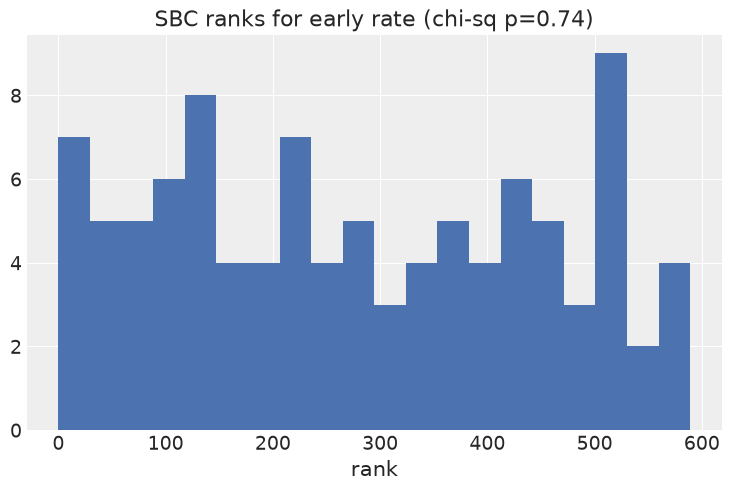

SBC: 100 sims | uniformity chi-square p=0.74 (>0.05 consistent with calibrated)


In [12]:
n_sim, ranks = 100, []
for i in range(n_sim):
    e_t = rng.exponential(1.0); l_t = rng.exponential(1.0); sw = rng.integers(1, n)
    yt = np.where(np.arange(n) < sw, rng.poisson(e_t, n), rng.poisson(l_t, n)).astype(float)
    with pm.Model() as ms:
        e = pm.Exponential("e", 1.0); l = pm.Exponential("l", 1.0)
        lpe = yt*pt.log(e)-e-pt.gammaln(yt+1); lpl = yt*pt.log(l)-l-pt.gammaln(yt+1)
        ce = pt.concatenate([[0.0], pt.cumsum(lpe)]); cl = pt.concatenate([[0.0], pt.cumsum(lpl)])
        k = pt.arange(1, n); LL = ce[k] + (cl[-1]-cl[k])
        pm.Potential("m", pt.logsumexp(LL)-pt.log(n-1))
        ids = pm.sample(300, tune=400, chains=2, random_seed=i, progressbar=False)
    d = ids.posterior["e"].values.ravel(); ranks.append(int((d < e_t).sum()))
ranks = np.array(ranks); L = len(d)
chi = st.chisquare(np.histogram(ranks, bins=10, range=(0,L))[0]).pvalue
plt.hist(ranks, bins=20, color="#4c72b0"); plt.title(f"SBC ranks for early rate (chi-sq p={chi:.2f})"); plt.xlabel("rank"); plt.show()
print(f"SBC: {n_sim} sims | uniformity chi-square p={chi:.2f} (>0.05 consistent with calibrated)")

## Stage 10 — Power-scaling prior sensitivity (rates)

In [13]:
post = az.extract(idata_m); ed = post["e"].values; ld = post["l"].values
lp = st.expon.logpdf(ed) + st.expon.logpdf(ld)
print("alpha   E[early]  E[late]")
for al in [0.8,1.0,1.25]:
    wgt=np.exp((al-1)*lp); wgt/=wgt.sum(); print(f" {al:4.2f}   {np.sum(wgt*ed):.3f}   {np.sum(wgt*ld):.3f}")

alpha   E[early]  E[late]
 0.80   3.079   0.939
 1.00   3.063   0.936
 1.25   3.042   0.933


## Stage 11–12 — Expansion, decision

**Next model (Stage 11):** allow a **gradual** transition (logistic ramp instead of a hard step), or
**multiple** changepoints — the marginalized machinery generalizes to a hidden Markov / state-space rate.

**Decision (Stage 12) — headline:** *British coal-mining disasters fell abruptly around the turn of the
20th century, from ~3 per year to ~1 per year; the discrete-switchpoint model (compound-sampled, judged
by R̂/ESS and switchpoint mixing rather than divergence count) and its full-NUTS marginalized twin agree,
and SBC confirms calibration.*

In [14]:
idata_m.to_netcdf("report/P19_idata.nc"); print("saved report/P19_idata.nc")

saved report/P19_idata.nc


## Exercises
1. Replace the hard switch with a logistic ramp `rate = l + (e−l)·sigmoid((s−i)/w)` and estimate the
   transition width w. Does LOO prefer it?
2. In Model A, raise/lower the Metropolis tuning and watch the switchpoint's ESS — why is mixing the
   right diagnostic for a discrete latent?
3. Add a second switchpoint and use LOO to ask whether the data support one change or two.